In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Walmart.zip to Walmart.zip


## Extracting the Dataset

In [ ]:
import zipfile
import os

with zipfile.ZipFile("Walmart.zip", "r") as zip_ref:
    zip_ref.extractall("Walmart_Data")

print("Files extracted successfully!")
print(os.listdir("Walmart_Data"))

Files extracted successfully!
['Capstone-Project-DS-With-R-3-2-1-1.pdf', 'Walmart DataSet.csv', 'walmart(letsee) (1).ipynb']


## Loading the Walmart Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("Walmart_Data/Walmart DataSet.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## First Five Rows of the Dataset

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Understanding the Dataset

In [ ]:
print("Number of rows and columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Number of rows and columns: (6435, 8)

Column Names:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


## Checking for Missing Values

In [ ]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


## Checking for Duplicate Records

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


## Converting Date Column into Date Format

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("Date column converted successfully!")
print(df.dtypes)

Date column converted successfully!
Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


## Statistical Summary of the Dataset

In [ ]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


## Number of Stores

In [ ]:
print("Number of unique stores:", df['Store'].nunique())
print("Store numbers:", sorted(df['Store'].unique()))

Number of unique stores: 45
Store numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45)]


## Total and Average Weekly Sales by Store

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].agg(
    Total_Sales='sum',
    Average_Weekly_Sales='mean'
).sort_values('Total_Sales', ascending=False)

store_sales

,Total_Sales,Average_Weekly_Sales
Store,,
20,3.013978e+08,2.107677e+06
4,2.995440e+08,2.094713e+06
14,2.889999e+08,2.020978e+06
13,2.865177e+08,2.003620e+06
2,2.753824e+08,1.925751e+06
10,2.716177e+08,1.899425e+06
27,2.538559e+08,1.775216e+06
6,2.237561e+08,1.564728e+06
1,2.224028e+08,1.555264e+06


## Top 10 Performing Stores

In [ ]:
top_10_stores = store_sales.head(10)

top_10_stores

,Total_Sales,Average_Weekly_Sales
Store,,
20,3.013978e+08,2.107677e+06
4,2.995440e+08,2.094713e+06
14,2.889999e+08,2.020978e+06
13,2.865177e+08,2.003620e+06
2,2.753824e+08,1.925751e+06
10,2.716177e+08,1.899425e+06
27,2.538559e+08,1.775216e+06
6,2.237561e+08,1.564728e+06
1,2.224028e+08,1.555264e+06


## Top 10 Stores by Total Sales

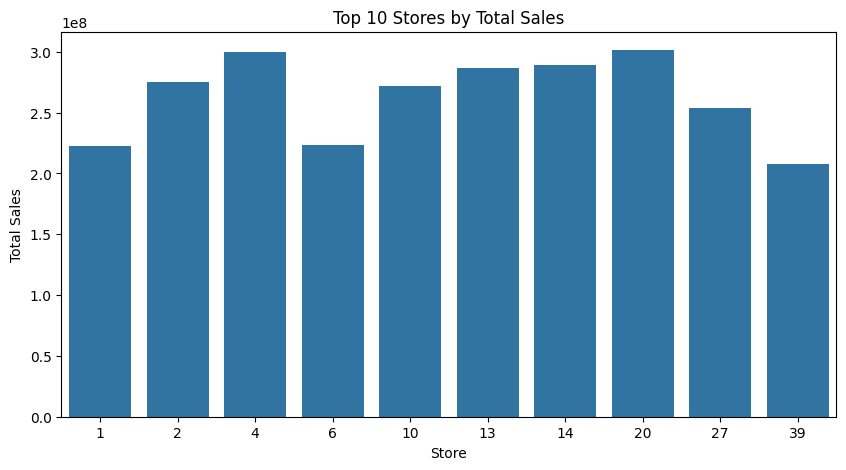

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_10_stores.index,
    y=top_10_stores['Total_Sales']
)

plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

## Bottom 10 Performing Stores

In [ ]:
bottom_10_stores = store_sales.tail(10).sort_values('Total_Sales')

bottom_10_stores

,Total_Sales,Average_Weekly_Sales
Store,,
33,37160221.96,259861.692028
44,43293087.84,302748.866014
5,45475688.90,318011.810490
36,53412214.97,373511.992797
38,55159626.42,385731.653287
3,57586735.07,402704.441049
30,62716885.12,438579.616224
37,74202740.32,518900.281958
16,74252425.40,519247.730070


## Bottom 10 Stores by Total Sales

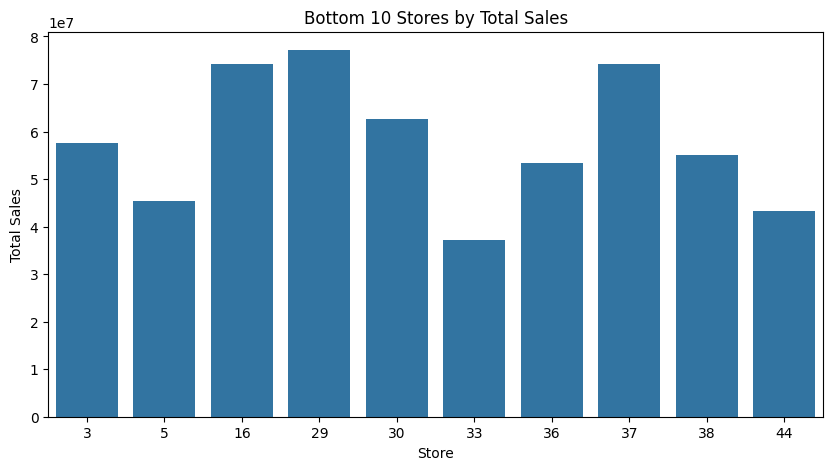

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=bottom_10_stores.index,
    y=bottom_10_stores['Total_Sales']
)

plt.title('Bottom 10 Stores by Total Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

## Weekly Sales Trend Over Time

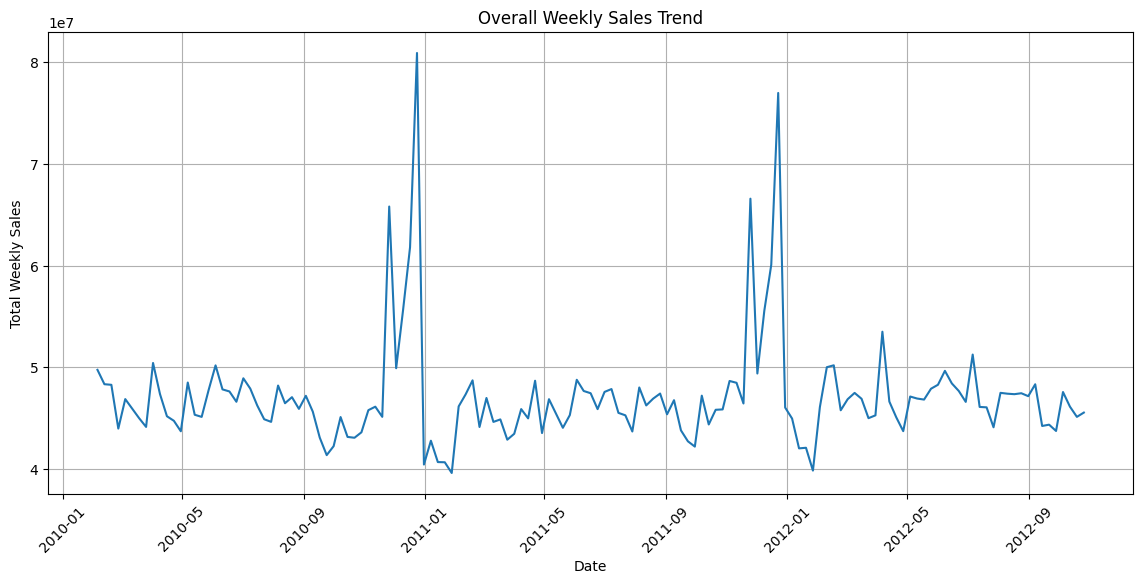

In [ ]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 6))

plt.plot(weekly_sales.index, weekly_sales.values)

plt.title('Overall Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Creating Month and Year Features

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print(df[['Date', 'Year', 'Month']].head())

        Date  Year  Month
0 2010-02-05  2010      2
1 2010-02-12  2010      2
2 2010-02-19  2010      2
3 2010-02-26  2010      2
4 2010-03-05  2010      3


## Monthly Sales Trend

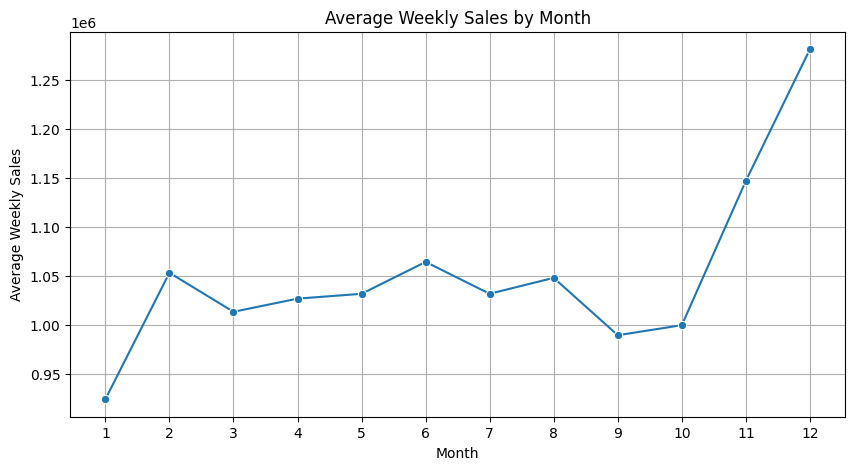

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## Holiday vs Non-Holiday Sales

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


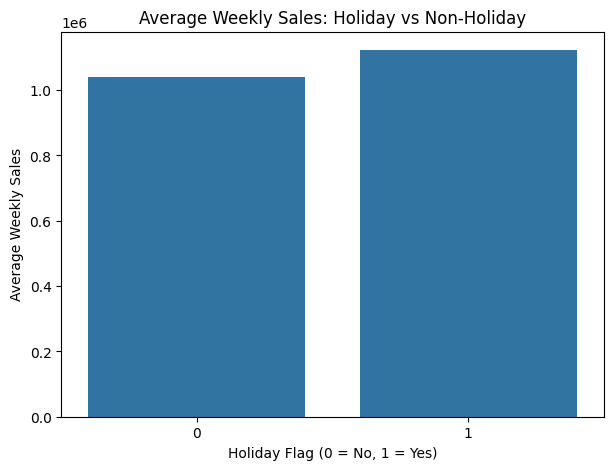

In [ ]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print(holiday_sales)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Holiday Flag (0 = No, 1 = Yes)')
plt.ylabel('Average Weekly Sales')
plt.show()

## Relationship Between Unemployment and Weekly Sales

In [ ]:
correlation_unemployment = df['Unemployment'].corr(df['Weekly_Sales'])

print("Correlation between Unemployment and Weekly Sales:",
      correlation_unemployment)

Correlation between Unemployment and Weekly Sales: -0.10617608965795429


## Unemployment Rate vs Weekly Sales

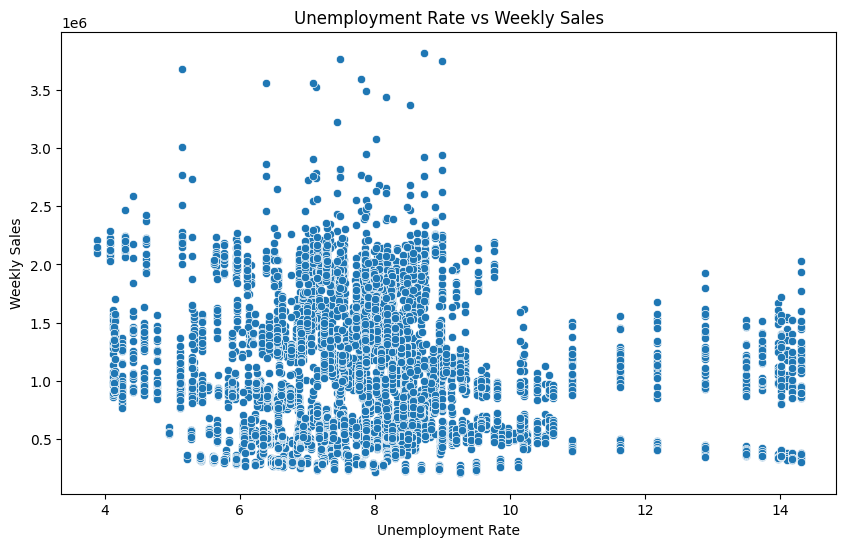

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales'
)

plt.title('Unemployment Rate vs Weekly Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.show()

## Store-wise Relationship Between Unemployment and Sales

In [ ]:
store_unemployment_corr = df.groupby('Store').apply(
    lambda x: x['Unemployment'].corr(x['Weekly_Sales'])
)

store_unemployment_corr = store_unemployment_corr.sort_values()

store_unemployment_corr

/tmp/ipykernel_1040/373056468.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_unemployment_corr = df.groupby('Store').apply(


,0
Store,
38,-0.785290
44,-0.780076
39,-0.384681
42,-0.356355
41,-0.350630
4,-0.337015
17,-0.263600
3,-0.230413
37,-0.221287


In [ ]:
print("Stores with strongest negative relationship:")

print(store_unemployment_corr.head(10))

Stores with strongest negative relationship:
Store
38   -0.785290
44   -0.780076
39   -0.384681
42   -0.356355
41   -0.350630
4    -0.337015
17   -0.263600
3    -0.230413
37   -0.221287
5    -0.207043
dtype: float64


## Relationship Between Temperature and Weekly Sales

In [ ]:
temperature_corr = df['Temperature'].corr(df['Weekly_Sales'])

print("Correlation between Temperature and Weekly Sales:",
      temperature_corr)

Correlation between Temperature and Weekly Sales: -0.06381001317946955


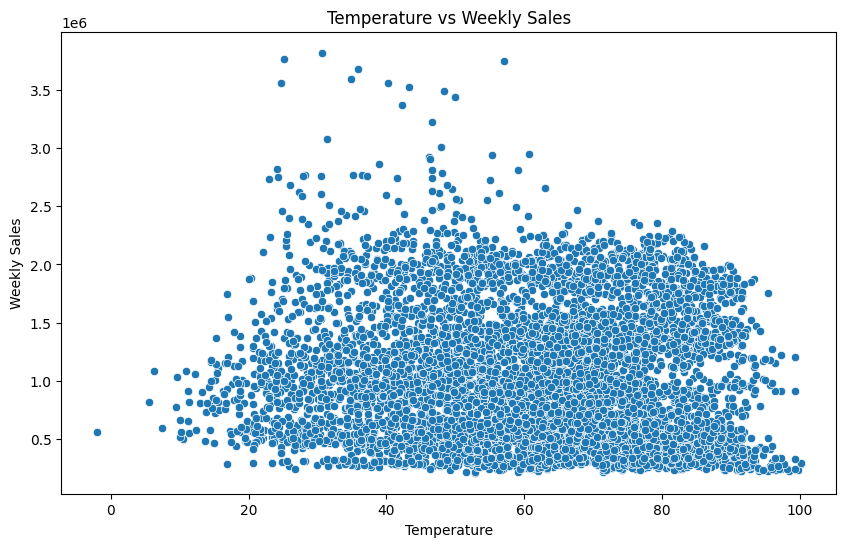

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Temperature',
    y='Weekly_Sales'
)

plt.title('Temperature vs Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

## Relationship Between CPI and Weekly Sales

In [ ]:
cpi_corr = df['CPI'].corr(df['Weekly_Sales'])

print("Correlation between CPI and Weekly Sales:",
      cpi_corr)

Correlation between CPI and Weekly Sales: -0.07263416204017632


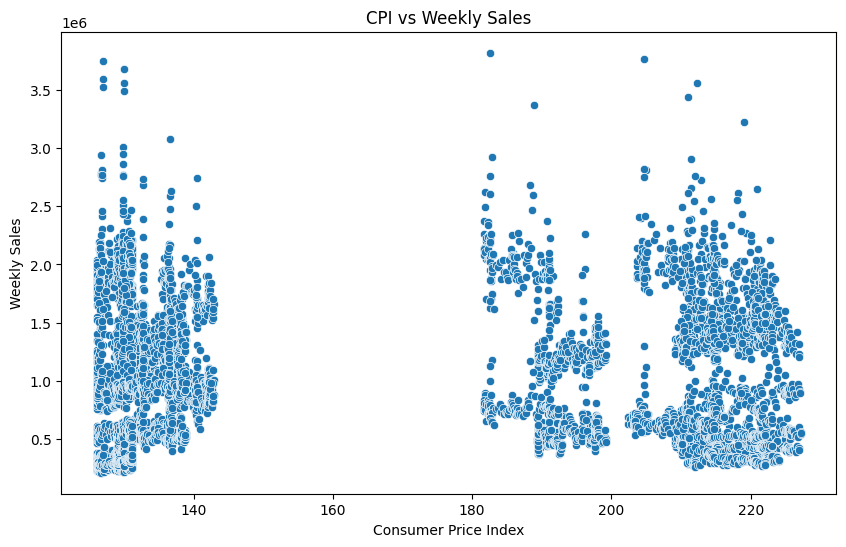

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='CPI',
    y='Weekly_Sales'
)

plt.title('CPI vs Weekly Sales')
plt.xlabel('Consumer Price Index')
plt.ylabel('Weekly Sales')
plt.show()

## Outlier Analysis of Weekly Sales

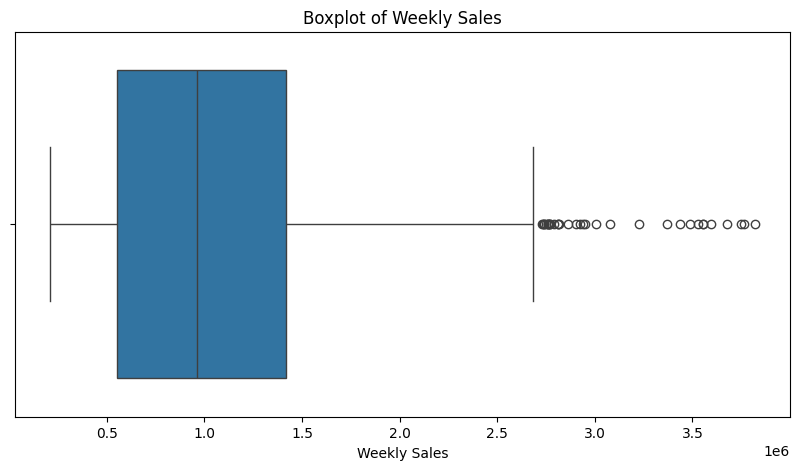

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Weekly_Sales'])

plt.title('Boxplot of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.show()

## Detecting Outliers Using IQR Method

In [ ]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Weekly_Sales'] < lower_bound) |
    (df['Weekly_Sales'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 553350.105
Q3: 1420158.66
IQR: 866808.5549999999
Lower Bound: -746862.7275
Upper Bound: 2720371.4924999997
Number of outliers: 34


## Highest and Lowest Performing Stores

In [ ]:
highest_store = store_sales['Total_Sales'].idxmax()
lowest_store = store_sales['Total_Sales'].idxmin()

highest_sales = store_sales.loc[highest_store, 'Total_Sales']
lowest_sales = store_sales.loc[lowest_store, 'Total_Sales']

difference = highest_sales - lowest_sales

print("Highest Performing Store:", highest_store)
print("Highest Total Sales:", highest_sales)

print("\nLowest Performing Store:", lowest_store)
print("Lowest Total Sales:", lowest_sales)

print("\nDifference between Highest and Lowest Sales:", difference)

Highest Performing Store: 20
Highest Total Sales: 301397792.46

Lowest Performing Store: 33
Lowest Total Sales: 37160221.96

Difference between Highest and Lowest Sales: 264237570.49999997


# Sales Forecasting for the Next 12 Weeks

In [ ]:
!pip install prophet -q

In [ ]:
from prophet import Prophet

In [ ]:
# Create a dictionary to store forecasts
store_forecasts = {}

# Loop through each store
for store in sorted(df['Store'].unique()):

    store_data = df[df['Store'] == store][['Date', 'Weekly_Sales']].copy()

    store_data = store_data.rename(columns={
        'Date': 'ds',
        'Weekly_Sales': 'y'
    })

    store_data = store_data.sort_values('ds')

    # Create and train Prophet model
    model = Prophet()
    model.fit(store_data)

    # Create future dates for next 12 weeks
    future = model.make_future_dataframe(periods=12, freq='W')

    # Generate forecast
    forecast = model.predict(future)

    # Keep only the next 12 weeks
    future_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

    store_forecasts[store] = future_forecast

print("Forecasting completed for all stores!")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

Forecasting completed for all stores!


## Forecast for Store 1

In [ ]:
store_forecasts[1]

,ds,yhat,yhat_lower,yhat_upper
143,2012-10-28,1.533722e+06,1.394530e+06,1.668981e+06
144,2012-11-04,1.599967e+06,1.463230e+06,1.735956e+06
145,2012-11-11,1.690155e+06,1.551356e+06,1.824288e+06
146,2012-11-18,1.747222e+06,1.615424e+06,1.882389e+06
147,2012-11-25,1.768337e+06,1.629494e+06,1.892016e+06
148,2012-12-02,1.810912e+06,1.669415e+06,1.947372e+06
149,2012-12-09,1.913995e+06,1.777513e+06,2.046408e+06
150,2012-12-16,2.024516e+06,1.897571e+06,2.157340e+06
151,2012-12-23,2.026088e+06,1.893855e+06,2.159191e+06
152,2012-12-30,1.856235e+06,1.724405e+06,1.989188e+06


## Sales Forecast for Store 1

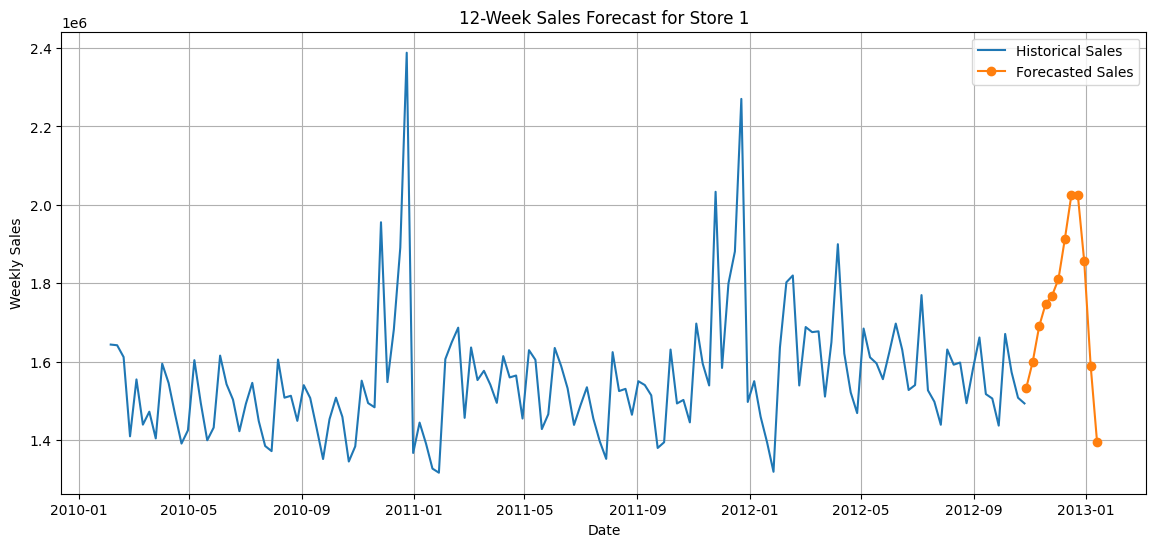

In [ ]:
store = 1

store_data = df[df['Store'] == store][['Date', 'Weekly_Sales']].copy()

forecast_data = store_forecasts[store]

plt.figure(figsize=(14, 6))

plt.plot(
    store_data['Date'],
    store_data['Weekly_Sales'],
    label='Historical Sales'
)

plt.plot(
    forecast_data['ds'],
    forecast_data['yhat'],
    marker='o',
    label='Forecasted Sales'
)

plt.title(f'12-Week Sales Forecast for Store {store}')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

## Forecasted Sales for All Stores

In [ ]:
all_forecasts = []

for store, forecast in store_forecasts.items():

    temp = forecast.copy()
    temp['Store'] = store

    all_forecasts.append(temp)

all_forecasts = pd.concat(all_forecasts, ignore_index=True)

all_forecasts = all_forecasts[
    ['Store', 'ds', 'yhat', 'yhat_lower', 'yhat_upper']
]

all_forecasts.head(15)

,Store,ds,yhat,yhat_lower,yhat_upper
0,1,2012-10-28,1.533722e+06,1.394530e+06,1.668981e+06
1,1,2012-11-04,1.599967e+06,1.463230e+06,1.735956e+06
2,1,2012-11-11,1.690155e+06,1.551356e+06,1.824288e+06
3,1,2012-11-18,1.747222e+06,1.615424e+06,1.882389e+06
4,1,2012-11-25,1.768337e+06,1.629494e+06,1.892016e+06
5,1,2012-12-02,1.810912e+06,1.669415e+06,1.947372e+06
6,1,2012-12-09,1.913995e+06,1.777513e+06,2.046408e+06
7,1,2012-12-16,2.024516e+06,1.897571e+06,2.157340e+06
8,1,2012-12-23,2.026088e+06,1.893855e+06,2.159191e+06
9,1,2012-12-30,1.856235e+06,1.724405e+06,1.989188e+06


## Total Forecasted Sales for the Next 12 Weeks

In [ ]:
total_forecast = all_forecasts.groupby('ds')['yhat'].sum()

total_forecast

,yhat
ds,
2012-10-28,4.529582e+07
2012-11-04,4.741000e+07
2012-11-11,5.035178e+07
2012-11-18,5.251721e+07
2012-11-25,5.406358e+07
2012-12-02,5.676710e+07
2012-12-09,6.125770e+07
2012-12-16,6.496207e+07
2012-12-23,6.379191e+07


## Overall Sales Forecast for the Next 12 Weeks

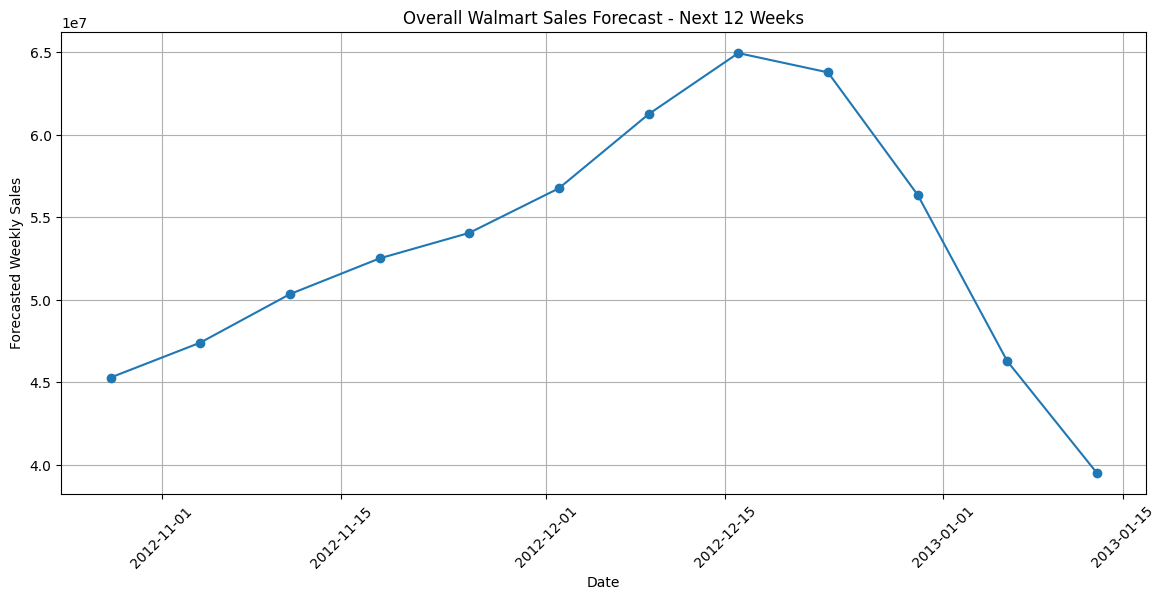

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    total_forecast.index,
    total_forecast.values,
    marker='o'
)

plt.title('Overall Walmart Sales Forecast - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Forecasted Weekly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Top Stores Based on 12-Week Forecast

In [ ]:
forecast_store_summary = all_forecasts.groupby('Store')['yhat'].sum().sort_values(
    ascending=False
)

print("Top 10 stores based on forecasted sales:")
forecast_store_summary.head(10)

Top 10 stores based on forecasted sales:


,yhat
Store,
4,3.047912e+07
20,2.931113e+07
13,2.837467e+07
2,2.645417e+07
10,2.632113e+07
14,2.378843e+07
27,2.203713e+07
39,2.192357e+07
6,2.138450e+07


## Lowest Performing Stores Based on 12-Week Forecast

In [ ]:
print("Bottom 10 stores based on forecasted sales:")
forecast_store_summary.tail(10).sort_values()

## Saving Forecast Results

In [ ]:
all_forecasts.to_csv(
    'Walmart_12_Week_Sales_Forecast.csv',
    index=False
)

print("Forecast file saved successfully!")

Forecast file saved successfully!


# Conclusion

The Walmart sales dataset was analyzed using statistical analysis, exploratory data analysis, outlier analysis, and data preprocessing techniques.

The analysis examined the relationship between weekly sales and unemployment, temperature, and Consumer Price Index (CPI). Seasonal patterns in weekly sales were also analyzed along with holiday-related sales behavior.

The historical performance of different Walmart stores was compared to identify the top-performing and worst-performing stores.

Finally, a predictive forecasting model was developed to forecast weekly sales for each store for the next 12 weeks. These forecasts can help Walmart improve inventory planning, supply management, and demand forecasting.